# Preexperimento (3/3): Presentación screening por fuente y candidatas FFD

Objetivo: generar figuras exportables (PNG bajo `reports/figures/presentacion/`) para situar:

1. **Screening de columnas** (`run_source_column_screening`): candidatos evaluados frente a columnas marcadas como `recommended` según el agregado por folds (frecuencia de selección e importancia media).
2. **Diferenciación fraccionaria (FFD)**: cuántas variables únicas reciben `recommended_action == apply` en al menos un símbolo, agrupadas por **tipo de origen** de la columna (backbone OHLCV, indicadores técnicos, bloques opcionales derivados / on-chain / microestructura / sentimiento / atención).

**Relación con el resto del preexperimento:** consume el manifest y los CSV de la corrida documentada en `02_resultados_screening_columnas_por_fuente.ipynb` y los resúmenes FFD de `01_evaluacion_fracdiff.ipynb`; actúa como síntesis visual para presentación (parte 3/3).

Entradas esperadas (si falta alguna, el notebook indica la ruta):

- `reports/validation/source_column_screening/latest_manifest.json` -> CSV de la última corrida de screening.
- `reports/eda/fracdiff/screening/screening_feature_summary.csv` (y, si aplica, `screening_all_symbols.csv`).
- Opcional: `reports/eda/fracdiff/screening/screening_contextual_feature_summary.csv` si se ejecutó el bloque contextual en `01_evaluacion_fracdiff.ipynb`.

**Productos:** figuras bajo `reports/figures/presentacion/`:

- `screening_columnas_unicas_vs_recomendadas_por_fuente.png`
- `ffd_variables_apply_por_tipo_origen.png`

Nota: la figura de screening de columnas usa la unión de nombres por fuente para priorizar claridad visual en presentación.



In [1]:
from __future__ import annotations

import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

ROOT = Path.cwd().resolve()
for p in (ROOT, *ROOT.parents):
    if (p / "pytest.ini").is_file() and (p / "src").is_dir():
        ROOT = p
        break
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.features.experimental_column_inventory import resolve_experimental_optional_block
from src.features.multisource_backbone_contract import OHLCV_BACKBONE_COLUMNS

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({"figure.dpi": 120, "savefig.dpi": 200, "font.size": 10})

FIG_DIR = ROOT / "reports" / "figures" / "presentacion"
FIG_DIR.mkdir(parents=True, exist_ok=True)


def ffd_variable_bucket(series_name: str) -> str:
    """Etiqueta de presentación alineada con el cribado de columnas -> ohlcv / técnico / bloque opcional."""
    if series_name in OHLCV_BACKBONE_COLUMNS:
        return "ohlcv"
    block = resolve_experimental_optional_block(series_name)
    if block is not None:
        return block.value
    if series_name.startswith(
        ("ta_", "tech_", "rsi", "macd", "bb_", "atr", "sma_", "ema_", "stoch", "mfi", "roc_", "rolling_", "vol_sma", "slope_")
    ):
        return "technical_indicators"
    return "technical_or_derived"


SCREENING_LABEL_ES: dict[str, str] = {
    "core_only": "Core (OHLCV + técnicos)",
    "derivatives_futures": "+ Derivados (futuros)",
    "onchain": "+ On-chain",
    "microstructure": "+ Microestructura",
    "sentiment": "+ Sentimiento",
    "attention": "+ Atención (trends / wiki / …)",
}

FFD_BUCKET_LABEL_ES: dict[str, str] = {
    "ohlcv": "OHLCV",
    "technical_indicators": "Indicadores técnicos",
    "technical_or_derived": "Derivadas / resto",
    "derivatives_futures": "Derivados",
    "onchain": "On-chain",
    "microstructure": "Microestructura",
    "sentiment": "Sentimiento",
    "attention": "Atención",
}

print(f"Raíz del repo: {ROOT}")
print(f"Figuras -> {FIG_DIR}")

Raíz del repo: /app
Figuras -> /app/reports/figures/presentacion


## 1. Screening: variables por tipo de configuración de fuente

Se lee la última corrida registrada en `latest_manifest.json`. La tabla descriptiva inicial usa `source_summary.csv`; la figura agrega por `column_summary.csv` la unión de nombres distintos por `source_subset_id`.

La figura muestra, para cada fuente, la **unión de nombres de columna distintos** evaluados en alguna fila frente a la **unión de nombres recomendados** (`recommended == True`) en alguna fila. Esta vista es más directa para presentación que el agregado por celda experimental, porque responde cuántas variables únicas aporta cada bloque antes y después del cribado.


In [2]:
manifest_path = ROOT / "reports" / "validation" / "source_column_screening" / "latest_manifest.json"
if not manifest_path.is_file():
    raise FileNotFoundError(
        "Ejecuta antes el screening o copia un manifiesto válido en "
        f"{manifest_path.parent}"
    )

manifest = json.loads(manifest_path.read_text(encoding="utf-8"))
run_dir = ROOT / manifest["paths"]["manifest_json"]
run_dir = run_dir.parent

source_summary_path = run_dir / "source_summary.csv"
column_summary_path = run_dir / "column_summary.csv"
source_df = pd.read_csv(source_summary_path)
column_df = pd.read_csv(column_summary_path)

SUBSET_ORDER = list(manifest["config"]["source_subset_ids"])

print("Corrida:", manifest.get("run_id"))
print(source_summary_path)
display(source_df.groupby("source_subset_id")[["n_columns_screened", "n_columns_recommended"]].describe().T)


Corrida: source_screening_lstm_real_20260426T1430
/app/reports/validation/source_column_screening/source_screening_lstm_real_20260426T1430/source_summary.csv


source_subset_id             attention  core_only  derivatives_futures  \
n_columns_screened    count  30.000000  30.000000            30.000000   
                      mean   40.000000  29.000000            33.200000   
                      std     0.000000   0.000000             8.543600   
                      min    40.000000  29.000000            29.000000   
                      25%    40.000000  29.000000            29.000000   
                      50%    40.000000  29.000000            29.000000   
                      75%    40.000000  29.000000            29.000000   
                      max    40.000000  29.000000            50.000000   
n_columns_recommended count  30.000000  30.000000            30.000000   
                      mean   17.133333  12.833333            13.900000   
                      std     9.317145   5.919479             6.676516   
                      min     2.000000   3.000000             4.000000   
                      25%     5.000000   5.250000             5.250000   
                      50%    22.000000  15.500000            16.500000   
                      75%    23.750000  17.000000            17.750000   
                      max    26.000000  20.000000            26.000000   

source_subset_id             microstructure    onchain  sentiment  
n_columns_screened    count       30.000000  30.000000  30.000000  
                      mean        41.600000  37.400000  31.400000  
                      std          0.813676   4.343842   0.498273  
                      min         40.000000  29.000000  31.000000  
                      25%         42.000000  39.000000  31.000000  
                      50%         42.000000  39.000000  31.000000  
                      75%         42.000000  39.000000  32.000000  
                      max         42.000000  41.000000  32.000000  
n_columns_recommended count       30.000000  30.000000  30.000000  
                      mean        15.666667  18.066667  13.800000  
                      std          9.488045   7.286896   6.945105  
                      min          3.000000   4.000000   2.000000  
                      25%          6.000000  10.000000   5.000000  
                      50%         17.500000  22.000000  17.000000  
                      75%         24.750000  23.000000  19.000000  
                      max         27.000000  27.000000  22.000000

,source_subset_id,n_columnas_distintas,n_recomendadas_distintas,etiqueta
1,core_only,29,27,Core (OHLCV + técnicos)
2,derivatives_futures,50,38,+ Derivados (futuros)
4,onchain,41,36,+ On-chain
3,microstructure,42,36,+ Microestructura
5,sentiment,32,27,+ Sentimiento
0,attention,56,49,+ Atención (trends / wiki / …)


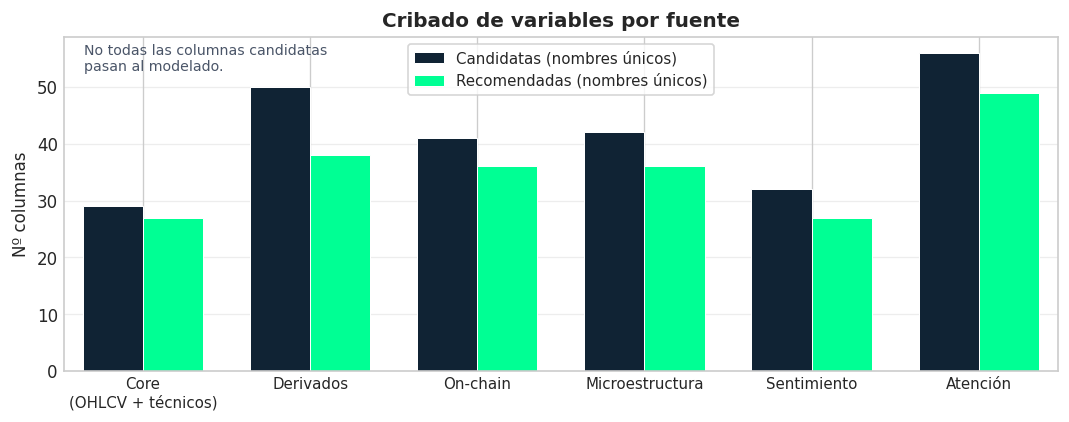

Guardado: /app/reports/figures/presentacion/screening_columnas_unicas_vs_recomendadas_por_fuente.png


In [3]:
# Vista B: columnas únicas por source_subset_id (sin duplicar nombres entre celdas)
uniq_rows: list[dict[str, object]] = []
for sid, grp in column_df.groupby("source_subset_id"):
    cols_all = grp["column"].unique()
    cols_rec = grp.loc[grp["recommended"], "column"].unique()
    uniq_rows.append(
        {
            "source_subset_id": sid,
            "n_columnas_distintas": len(cols_all),
            "n_recomendadas_distintas": len(set(cols_rec)),
        }
    )
uniq_df = pd.DataFrame(uniq_rows)
uniq_df["etiqueta"] = uniq_df["source_subset_id"].map(
    lambda x: SCREENING_LABEL_ES.get(str(x), str(x))
)
_order_map = {sid: i for i, sid in enumerate(SUBSET_ORDER)}
uniq_df["_k"] = uniq_df["source_subset_id"].map(lambda s: _order_map.get(str(s), 999))
uniq_df = uniq_df.sort_values("_k").drop(columns="_k")

display(uniq_df[["source_subset_id", "n_columnas_distintas", "n_recomendadas_distintas", "etiqueta"]])

# Figura presentación: etiquetas cortas, colores de marca, poco margen, anotación
ETIQUETAS_CRIBADO_PRESENTACION: dict[str, str] = {
    "core_only": "Core\n(OHLCV + técnicos)",
    "derivatives_futures": "Derivados",
    "onchain": "On-chain",
    "microstructure": "Microestructura",
    "sentiment": "Sentimiento",
    "attention": "Atención",
}
etiquetas_x = uniq_df["source_subset_id"].map(
    lambda sid: ETIQUETAS_CRIBADO_PRESENTACION.get(str(sid), str(sid))
)

COLOR_CANDIDATAS = "#102334"
COLOR_RECOMENDADAS = "#00ff94"

x = np.arange(len(uniq_df))
width = 0.36
fig, ax = plt.subplots(figsize=(9.2, 3.85))
ax.bar(
    x - width / 2,
    uniq_df["n_columnas_distintas"],
    width,
    label="Candidatas (nombres únicos)",
    color=COLOR_CANDIDATAS,
    edgecolor="white",
    linewidth=0.6,
)
ax.bar(
    x + width / 2,
    uniq_df["n_recomendadas_distintas"],
    width,
    label="Recomendadas (nombres únicos)",
    color=COLOR_RECOMENDADAS,
    edgecolor="white",
    linewidth=0.6,
)
ax.set_xticks(x)
ax.set_xticklabels(etiquetas_x, rotation=0, ha="center", fontsize=9)
ax.set_ylabel("Nº columnas", fontsize=10)
ax.set_title("Cribado de variables por fuente", fontsize=12, fontweight="semibold", pad=6)
ax.legend(frameon=True, fontsize=9, loc="upper center")
ax.margins(x=0.02)
ax.grid(axis="y", alpha=0.35)
ax.text(
    0.02,
    0.98,
    "No todas las columnas candidatas\npasan al modelado.",
    transform=ax.transAxes,
    fontsize=8.5,
    color="#4A5568",
    va="top",
    ha="left",
)
fig.tight_layout(pad=0.25, rect=[0.04, 0.06, 0.995, 0.94])
out_b = FIG_DIR / "screening_columnas_unicas_vs_recomendadas_por_fuente.png"
fig.savefig(out_b, bbox_inches="tight", pad_inches=0.08)
plt.show()
print(f"Guardado: {out_b}")




## 2. FFD: variables con acción `apply` por tipo de origen

Se usa `screening_feature_summary.csv` (agregado por `series_name` y símbolo). Una variable cuenta como **candidata FFD** si `apply_count >= 1`. La agrupación por `ffd_variable_bucket` usa el mismo criterio de negocio que el screening de columnas para etiquetar el prefijo/bloque.


Incorporado resumen contextual: /app/reports/eda/fracdiff/screening/screening_contextual_feature_summary.csv


,bucket,n_variables,n_con_apply,etiqueta
0,technical_or_derived,5,4,Derivadas / resto
1,ohlcv,7,4,OHLCV
2,technical_indicators,17,4,Indicadores técnicos
3,microstructure,5,2,Microestructura


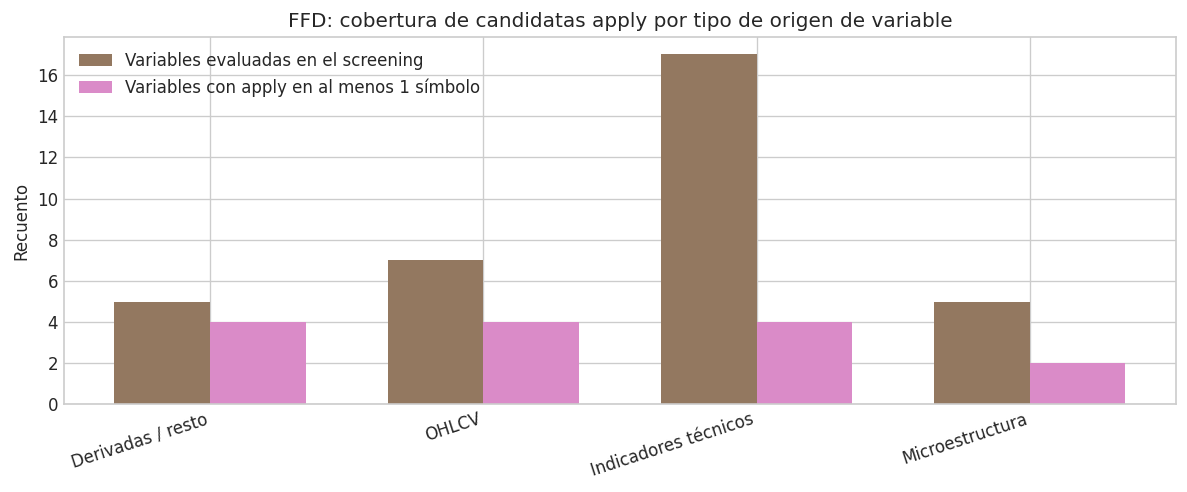

Guardado: /app/reports/figures/presentacion/ffd_variables_apply_por_tipo_origen.png


In [4]:
summary_path = ROOT / "reports" / "eda" / "fracdiff" / "screening" / "screening_feature_summary.csv"
ctx_path = ROOT / "reports" / "eda" / "fracdiff" / "screening" / "screening_contextual_feature_summary.csv"

if not summary_path.is_file():
    raise FileNotFoundError(
        "No hay resumen FFD. Ejecuta el bloque multisímbolo en "
        "notebooks/04_preexperimento/01_evaluacion_fracdiff.ipynb o ajusta la ruta."
    )

feat_df = pd.read_csv(summary_path)
feat_df["bucket"] = feat_df["series_name"].map(ffd_variable_bucket)

if ctx_path.is_file():
    ctx_df = pd.read_csv(ctx_path)
    ctx_df["bucket"] = ctx_df["series_name"].map(ffd_variable_bucket)
    feat_df = pd.concat([feat_df, ctx_df], ignore_index=True)
    feat_df = feat_df.sort_values("apply_count", ascending=False).drop_duplicates(
        "series_name", keep="first"
    )
    print(f"Incorporado resumen contextual: {ctx_path}")

feat_df["candidata_ffd"] = feat_df["apply_count"] >= 1
bucket_counts = (
    feat_df.groupby("bucket", sort=False)
    .agg(
        n_variables=("series_name", "count"),
        n_con_apply=("candidata_ffd", "sum"),
    )
    .reset_index()
)
bucket_counts["etiqueta"] = bucket_counts["bucket"].map(
    lambda b: FFD_BUCKET_LABEL_ES.get(str(b), str(b))
)
display(bucket_counts)

x = np.arange(len(bucket_counts))
width = 0.35
fig, ax = plt.subplots(figsize=(10, 4.2))
ax.bar(
    x - width / 2,
    bucket_counts["n_variables"],
    width,
    label="Variables evaluadas en el screening",
    color="#937860",
)
ax.bar(
    x + width / 2,
    bucket_counts["n_con_apply"],
    width,
    label="Variables con apply en al menos 1 símbolo",
    color="#DA8BC8",
)
ax.set_xticks(x)
ax.set_xticklabels(bucket_counts["etiqueta"], rotation=18, ha="right")
ax.set_ylabel("Recuento")
ax.set_title("FFD: cobertura de candidatas apply por tipo de origen de variable")
ax.legend()
fig.tight_layout()
out_ffd = FIG_DIR / "ffd_variables_apply_por_tipo_origen.png"
fig.savefig(out_ffd, bbox_inches="tight")
plt.show()
print(f"Guardado: {out_ffd}")

### Lectura rápida

- El **screening de modelado** reduce el espacio de columnas por importancia estabilizada y redundancia; la figura de la sección 1 muestra cuántos nombres únicos sobreviven al cribado por fuente.
- El **screening FFD** es independiente: decide estacionariedad y retención de memoria; las barras por `bucket` muestran dónde el método propone `apply` con más frecuencia entre símbolos.
- Si `screening_contextual_feature_summary.csv` está disponible, el gráfico FFD incluye buckets de bloques opcionales (p. ej. microestructura); si falta, queda limitado a OHLCV e indicadores técnicos hasta generarlo en `01_evaluacion_fracdiff.ipynb`.
